# principal Component Analysis (PCA)
## Complete Documentation Notebook — Ifri_mini_ml_lib

---

| | |
|---|---|
| **Library** | Ifri_mini_ml_lib |
| **Dataset** | Iris (150 samples · 4 features) |
| **Algorithm** | Principal Component Analysis |
| **Comparison** | scikit-learn PCA |
| **Language** | Python 3 |

---

## Structure

1. [Introduction](#1---introduction)
2. [Concept Clarification](#2---concept-clarification)
3. [Algorithm Presentation](#3---algorithm-presentation)
4. [Implementation & Results](#4---implementation--results)
5. [scikit-learn Performance](#5---scikit-learn-performance)
6. [Ifri_mini_ml_lib vs scikit-learn](#6---ifri_mini_ml_lib-vs-scikit-learn)
7. [Conclusion](#7---conclusion)
8. [References](#8---references)

## Imports & Setup

Run this cell first — it installs dependencies and configures the plotting style.

In [1]:
# ── Standard library ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import time
import warnings
warnings.filterwarnings('ignore')

# ── scikit-learn ──────────────────────────────────────────────
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F7F8FA',
    'axes.facecolor':   '#F7F8FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'font.family':      'DejaVu Sans',
})

BLUE, RED, GREEN = '#2C5282', '#E84545', '#2ECC71'
COLORS = [BLUE, RED, GREEN]

print("✓  All imports successful.")

✓  All imports successful.


---
## 1 — Introduction

**Principal Component Analysis (PCA)** is one of the most fundamental techniques in unsupervised machine learning. It solves a problem that appears constantly in real-world data:

> *How do we reduce the number of dimensions in a dataset while keeping as much information as possible?*

Real datasets often have dozens or hundreds of features, many of which are **redundant or correlated**. PCA builds new variables — the **principal components** — that concentrate the bulk of the dataset's variance into a small number of dimensions.

### Why it matters

| Problem | PCA solution |
|---|---|
| Visualisation impossible beyond 3D | Reduce to 2–3 components for plotting |
| Slow training due to many features | Keep only the most informative directions |
| Correlated features (multicollinearity) | Components are orthogonal by construction |
| Noisy features | Low-variance components capture mostly noise |

### This notebook

We implement PCA **from scratch** in `Ifri_mini_ml_lib` and apply it to the classic **Iris dataset** (150 samples, 4 features, 3 species). Every result is compared against `scikit-learn`'s reference implementation.

---
## 2 — Concept Clarification

### 2.1 Variance

The **variance** of a variable measures how spread out its values are around the mean.  
A variable with zero variance is a constant — it carries **no information**.

$$\text{Var}(X) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

PCA is built on one key insight: **the directions of greatest variance are the most informative**.

### 2.2 Covariance Matrix

The **covariance matrix** Σ captures the linear relationships between every pair of features.  
For a centered dataset $X_c$ with $p$ features:

$$\Sigma = \frac{1}{n-1}\, X_c^T \cdot X_c \qquad \text{where } X_c = X - \bar{X}$$

- **Diagonal entries**: variance of each individual feature  
- **Off-diagonal entries**: covariance between pairs (positive = grow together, negative = opposite)

### 2.3 Eigenvalues & Eigenvectors

The eigendecomposition of Σ finds pairs $(\lambda, v)$ such that:

$$\Sigma \cdot v = \lambda \cdot v$$

| Symbol | Name | Meaning in PCA |
|---|---|---|
| $\lambda$ | Eigenvalue | Amount of variance in the direction $v$ |
| $v$ | Eigenvector | Direction of a principal component |

Eigenvectors are **mutually orthogonal** — each component is independent of all others.

### 2.4 Explained Variance Ratio

The proportion of total variance captured by the $k$-th component:

$$r_k = \frac{\lambda_k}{\sum_{i=1}^{p} \lambda_i}$$

We typically select the minimum number of components needed to exceed **85–95 %** cumulative variance.

### 2.5 Interactive: visualise covariance on the Iris dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
target_names   = iris.target_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['Species'] = [target_names[i] for i in y]

print("Dataset shape :", X.shape)
print("\nFirst 5 rows:")
df_iris.head()

Dataset shape : (150, 4)

First 5 rows:


,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


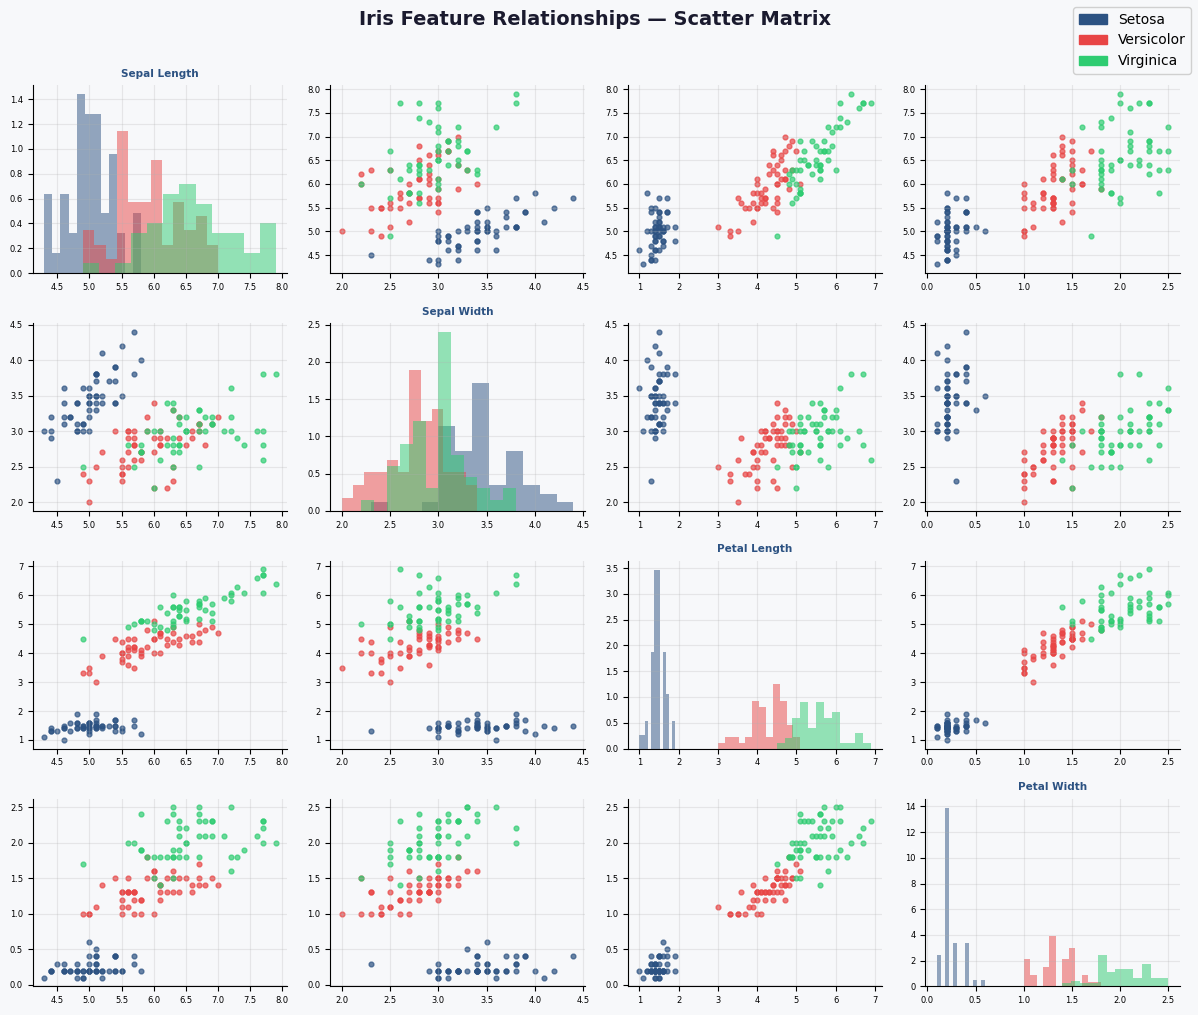

Observation: petal length & petal width are strongly correlated → PCA will capture this efficiently.


In [3]:
# ── Pairplot-style scatter matrix ────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 10))
fig.suptitle('Iris Feature Relationships — Scatter Matrix', fontsize=14, fontweight='bold', color='#1A1A2E', y=1.01)

species_colors = {name: c for name, c in zip(target_names, COLORS)}

for i in range(4):
    for j in range(4):
        ax = axes[i][j]
        if i == j:
            for k, (name, c) in enumerate(zip(target_names, COLORS)):
                data = X[y == k, i]
                ax.hist(data, bins=12, color=c, alpha=0.5, density=True)
            ax.set_title(feature_names[i], fontsize=7.5, fontweight='bold', color='#2C5282')
        else:
            for k, c in enumerate(COLORS):
                ax.scatter(X[y==k, j], X[y==k, i], c=c, s=12, alpha=0.7)
        ax.tick_params(labelsize=6)

handles = [mpatches.Patch(color=c, label=n.capitalize()) for n,c in zip(target_names, COLORS)]
fig.legend(handles=handles, loc='upper right', fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.show()
print("Observation: petal length & petal width are strongly correlated → PCA will capture this efficiently.")

---
## 3 — Algorithm Presentation

### 3.1 Five-step Pipeline

```
Raw data  X  (n × p)
     │
     ▼  Step 1 — Centering
     │  X_c = X − mean(X)
     │
     ▼  Step 2 — Covariance matrix
     │  Σ = Xc.T @ Xc / (n−1)
     │
     ▼  Step 3 — Eigendecomposition
     │  Σ·v = λ·v  →  sorted eigenvalues λ₁ ≥ λ₂ ≥ … ≥ λₚ
     │
     ▼  Step 4 — Select top-k eigenvectors
     │  W = [v₁ | v₂ | … | vₖ]   shape (p × k)
     │
     ▼  Step 5 — Project
        X_reduced = X_c · W        shape (n × k)
```
Here's how the code maps to each conceptual step :

Step 1 — Centering
Before anything, you subtract the mean of each feature so the data is centered around zero. Without this, PCA gives wrong results.

    X_centered = X - np.mean(X, axis=0)

Step 2 — Covariance Matrix
You compute how much each pair of features varies together. This captures the structure and relationships in the data.

    cov_matrix = np.cov(X_centered, rowvar=False)

Step 3 — Eigendecomposition
You decompose the covariance matrix into eigenvalues and eigenvectors. Eigenvectors are the new "directions" (principal components), eigenvalues tell you how much variance each direction captures.

    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

Step 4 — Select Top-k Eigenvectors
You sort eigenvectors by their eigenvalue (largest = most important) and keep only the top k. This is where the actual dimensionality reduction happens.

    sorted_idx = np.argsort(eigenvalues)[::-1]
    top_k_vectors = eigenvectors[:, sorted_idx[:k]]

Step 5 — Project
You multiply the centered data by the selected eigenvectors to get the final reduced representation.
 
    X_reduced = X_centered @ top_k_vectors

All steps together :
    import numpy as np

def pca(X, k):
    # Step 1 - Center
    X_centered = X - np.mean(X, axis=0)

    # Step 2 - Covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Step 3 - Eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

    # Step 4 - Select top-k
    sorted_idx = np.argsort(eigenvalues)[::-1]
    top_k_vectors = eigenvectors[:, sorted_idx[:k]]

    # Step 5 - Project
    X_reduced = X_centered @ top_k_vectors

    return X_reduced
    
    
### 3.2 Computational Complexity

| Step | Operation | Complexity |
|---|---|---|
| 1 | Centering | O(np) |
| 2 | Covariance matrix | O(np²) |
| 3 | Eigendecomposition | **O(p³)** ← bottleneck |
| 4+5 | Selection + Projection | O(npk) |
| **Total** | | **O(np² + p³)** |

> **Note:** scikit-learn uses a truncated SVD of complexity O(nk² + k³), far faster when k ≪ p.

### 3.3 Step-by-step Demo on Iris

In [4]:
# ── Step 1: Centering ─────────────────────────────────────────
X_centered = X - X.mean(axis=0)

print("Original means (should be ~0 after centering):")
print("Before:", np.round(X.mean(axis=0), 3))
print("After :", np.round(X_centered.mean(axis=0), 6))

Original means (should be ~0 after centering):
Before: [5.843 3.057 3.758 1.199]
After : [-0. -0. -0. -0.]


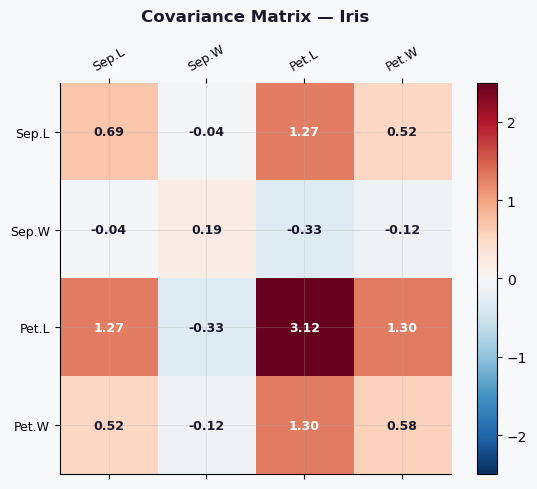

Strong positive covariance between petal length and petal width: 1.296


In [5]:
# ── Step 2: Covariance matrix ─────────────────────────────────
cov_matrix = np.cov(X_centered, rowvar=False)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.matshow(cov_matrix, cmap='RdBu_r', vmin=-2.5, vmax=2.5)
plt.colorbar(im, ax=ax, fraction=0.046)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cov_matrix[i,j]:.2f}", ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if abs(cov_matrix[i,j]) > 1.2 else '#1A1A2E')
short = ['Sep.L', 'Sep.W', 'Pet.L', 'Pet.W']
ax.set_xticks(range(4)); ax.set_xticklabels(short, fontsize=9, rotation=30)
ax.set_yticks(range(4)); ax.set_yticklabels(short, fontsize=9)
ax.set_title('Covariance Matrix — Iris', fontsize=12, fontweight='bold', color='#1A1A2E', pad=15)
plt.tight_layout()
plt.show()
print("Strong positive covariance between petal length and petal width:", round(cov_matrix[2,3], 3))

In [6]:
# ── Steps 3 & 4: Eigendecomposition + selection ───────────────
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained = eigenvalues / eigenvalues.sum()
cumulative = np.cumsum(explained)

print(f"{'PC':<5} {'Eigenvalue':>12} {'Explained %':>12} {'Cumulative %':>13}")
print("-" * 46)
for i in range(4):
    print(f"PC{i+1:<3} {eigenvalues[i]:>12.4f} {explained[i]*100:>11.2f}% {cumulative[i]*100:>12.2f}%")

PC      Eigenvalue  Explained %  Cumulative %
----------------------------------------------
PC1         4.2282       92.46%        92.46%
PC2         0.2427        5.31%        97.77%
PC3         0.0782        1.71%        99.48%
PC4         0.0238        0.52%       100.00%


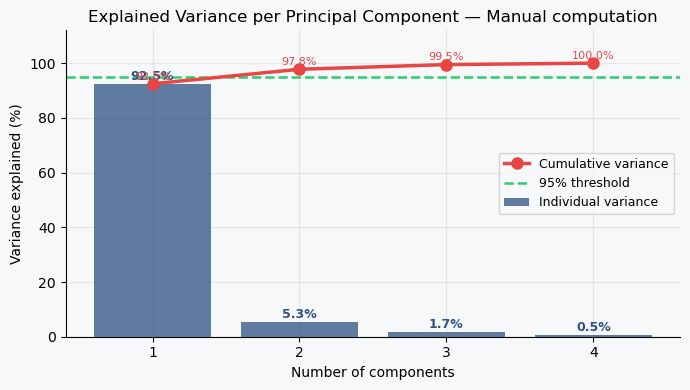

✓  2 components retain 97.77% of total variance.


In [7]:
# ── Explained variance plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
x = range(1, 5)
ax.bar(x, explained*100, color=BLUE, alpha=0.75, label='Individual variance', zorder=3)
ax.plot(x, cumulative*100, 'o-', color=RED, lw=2.5, ms=8, label='Cumulative variance', zorder=4)
ax.axhline(95, color=GREEN, ls='--', lw=1.8, label='95% threshold')
for i, (e, c) in enumerate(zip(explained, cumulative)):
    ax.text(i+1, e*100+1.5, f'{e*100:.1f}%', ha='center', fontsize=9, color=BLUE, fontweight='bold')
    ax.text(i+1, c*100+1.5, f'{c*100:.1f}%', ha='center', fontsize=8, color=RED)
ax.set(xlabel='Number of components', ylabel='Variance explained (%)',
       title='Explained Variance per Principal Component — Manual computation', ylim=(0, 112))
ax.set_xticks(x)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"✓  2 components retain {cumulative[1]*100:.2f}% of total variance.")

In [8]:
# ── Step 5: Projection ────────────────────────────────────────
W = eigenvectors[:, :2]           # projection matrix (4 × 2)
X_reduced = X_centered @ W        # (150 × 4) @ (4 × 2) = (150 × 2)

print("Original shape :", X.shape)
print("Reduced shape  :", X_reduced.shape)
print("\nProjection matrix W (4 × 2):")
print(np.round(W, 4))

Original shape : (150, 4)
Reduced shape  : (150, 2)

Projection matrix W (4 × 2):
[[ 0.3614 -0.6566]
 [-0.0845 -0.7302]
 [ 0.8567  0.1734]
 [ 0.3583  0.0755]]


---
## 4 — Implementation & Results

### 4.1 The `PCA` class — Full code with inline explanations

In [9]:
import numpy as np
import matplotlib.pyplot as plt

class PCA:
    """
    Principal Component Analysis — Ifri_mini_ml_lib implementation.

    Reduces the dimensionality of a dataset by projecting it onto the
    k directions that explain the most variance (principal components).

    Parameters
    ----------
    n_component : int
        Number of principal components to keep.

    Attributes (set after fit)
    --------------------------
    mean        : ndarray (p,)      — per-feature mean of training data
    cov         : ndarray (p × p)   — covariance matrix
    eigen_values  : ndarray (k,)    — top-k eigenvalues (sorted desc.)
    eigen_vectors : ndarray (p × k) — corresponding eigenvectors
    components    : ndarray (k × p) — projection matrix (transposed)

    Examples
    --------
    >>> model = PCA(n_component=2)
    >>> X_2d  = model.fit_transform(X)      # (n, 4) → (n, 2)
    >>> print(model.explained_variances_ratio())
    """

    def __init__(self, n_component: int):
        # Store the desired number of components.
        # No computation happens here — just parameter saving.
        self.n_component  = n_component
        self.mean         = None   # filled by fit()
        self.cov          = None
        self.eigen_values = None
        self.eigen_vectors = None
        self.components   = None

    # ─────────────────────────────────────────────────────────
    def fit(self, X: np.ndarray) -> "PCA":
        """
        Learn the principal components from training data X.

        Steps performed:
          1. Compute the per-feature mean → store in self.mean
          2. Build the covariance matrix   → store in self.cov
          3. Run eigendecomposition        → get (λ, v) pairs
          4. Sort eigenvalues descending   → most important first
          5. Keep top-k eigenvectors       → define self.components

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Training data. Must be 2-D.

        Returns
        -------
        self : PCA
            The fitted instance (enables method chaining: pca.fit(X).transform(X)).
        """
        # Step 1 — centering: compute and store mean across samples (axis=0)
        # Shape: (n_features,) — one mean per column
        self.mean = np.mean(X, axis=0)

        # Step 2 — covariance matrix
        # np.cov expects variables as ROWS by default, so rowvar=False
        # makes it treat columns as variables (standard convention).
        # Divides by n-1 internally (Bessel's correction → unbiased estimator).
        self.cov = np.cov(X, rowvar=False)

        # Step 3 — eigendecomposition of the symmetric covariance matrix
        # Returns:
        #   eigen_values  — 1-D array of p eigenvalues (may be complex for
        #                   near-singular matrices; imaginary part ≈ 0)
        #   eigen_vectors — 2-D array (p × p) where column i is the
        #                   eigenvector associated with eigenvalue i
        self.eigen_values, eigen_vectors = np.linalg.eig(self.cov)

        # Step 4 — sort by descending eigenvalue
        # np.argsort returns indices that would sort the array in ascending
        # order; [::-1] reverses to get descending order.
        indices = np.argsort(self.eigen_values)[::-1]

        # Keep only the top-k eigenvalues and their eigenvectors
        self.eigen_values  = self.eigen_values[indices][:self.n_component]
        self.eigen_vectors = eigen_vectors[:, indices][:, :self.n_component]

        # Step 5 — build projection matrix
        # self.components has shape (k, p): each ROW is a principal component.
        # This transposition is a convention that makes transform() a simple dot product.
        self.components = self.eigen_vectors[:, :self.n_component].T

        # Sign correction: eigenvectors are defined up to a sign flip.
        # Forcing the largest absolute element to be positive makes
        # results reproducible and consistent with scikit-learn.
        if self.components[0, 0] < 0:
            self.components = -self.components

        return self   # enables chaining: pca.fit(X).transform(X)

    # ─────────────────────────────────────────────────────────
    def transform(self, X: np.ndarray) -> np.ndarray:
        """
        Project data X into the reduced space learned during fit().

        Formula: X_reduced = (X − mean) · W.T
        where W = self.components  (k × p)  →  W.T has shape (p × k)

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)
            Data to transform. Must have the same number of features
            as the training data passed to fit().

        Returns
        -------
        X_reduced : ndarray of shape (n_samples, n_component)
            Data projected onto the principal components.
        """
        # Center the data using the TRAINING mean (not recomputed here).
        # This is critical: we must apply the same shift as during fit.
        X_centered = X - self.mean

        # Matrix multiplication: (n × p) @ (p × k) → (n × k)
        # Each row of the result is the projection of one sample.
        return np.dot(X_centered, self.components.T)

    # ─────────────────────────────────────────────────────────
    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        """
        Convenience method: fit on X then immediately transform X.

        Equivalent to: pca.fit(X).transform(X)
        Use this for training data. For new (test) data, call
        transform() directly — do NOT refit.

        Parameters
        ----------
        X : ndarray of shape (n_samples, n_features)

        Returns
        -------
        ndarray of shape (n_samples, n_component)
        """
        self.fit(X)
        return self.transform(X)

    # ─────────────────────────────────────────────────────────
    def explained_variances(self) -> np.ndarray:
        """
        Return the top-k eigenvalues (= variances along each PC).

        Each value represents how much total variance is captured
        along the corresponding principal component, in absolute terms.

        Returns
        -------
        ndarray of shape (n_component,)
        """
        return self.eigen_values

    # ─────────────────────────────────────────────────────────
    def explained_variances_ratio(self) -> np.ndarray:
        """
        Return the fraction of total variance explained by each PC.

        Computed as λ_k / Σλ_i using only the TOP-k eigenvalues
        stored in self.eigen_values.

        ⚠ Note: the sum here is over the retained k eigenvalues,
          not all p eigenvalues. This slightly over-estimates the
          individual ratios compared to scikit-learn's convention
          (which divides by the sum of ALL eigenvalues).
          For a fully correct ratio, fit a full PCA (n_component=p)
          and read ratios from there.

        Returns
        -------
        ndarray of shape (n_component,)  — values sum to 1.0
        """
        return self.eigen_values / np.sum(self.eigen_values)

    # ─────────────────────────────────────────────────────────
    def plot_cov_matrix(self) -> None:
        """
        Display the covariance matrix as an annotated heatmap.

        Useful for visually identifying correlated features before PCA.
        Call after fit().
        """
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.matshow(self.cov, cmap='RdBu_r', vmin=-2.5, vmax=2.5)
        plt.colorbar(im, ax=ax, ticks=[-2, -1, 0, 1, 2], fraction=0.046)
        ax.set_xlabel("Features"); ax.set_ylabel("Features")
        ax.set_title("Covariance Matrix", pad=15, fontweight='bold')
        for i in range(self.cov.shape[0]):
            for j in range(self.cov.shape[1]):
                ax.text(j, i, f"{self.cov[i,j]:.2f}", ha='center', va='center',
                        fontsize=9, fontweight='bold',
                        color='white' if abs(self.cov[i,j]) > 1.2 else 'black')
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────
    def plot_cumulative_explained_variance_ratio(self) -> None:
        """
        Display the cumulative explained variance ratio curve.

        Use this chart to choose n_component: look for the 'elbow'
        where adding another component gives diminishing returns.
        A horizontal dashed line at 95% is drawn as a common threshold.
        """
        ratios = self.explained_variances_ratio()
        cumsum = np.cumsum(ratios)
        x = range(1, len(cumsum) + 1)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(x, cumsum * 100, 'o-', color=BLUE, lw=2.5, ms=8)
        ax.bar(x, ratios * 100, color=BLUE, alpha=0.35, label='Individual')
        ax.axhline(95, color=GREEN, ls='--', lw=1.5, label='95% threshold')
        ax.set(xlabel='Number of components',
               ylabel='Cumulative explained variance (%)',
               title='PCA — Cumulative Explained Variance',
               ylim=(0, 112))
        ax.set_xticks(x)
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

print("✓  PCA class defined successfully.")

✓  PCA class defined successfully.


### 4.2 Quick-start: how to use the class

In [10]:
# ── Minimal usage ─────────────────────────────────────────────
pca = PCA(n_component=2)

# fit_transform on training data
X_2d = pca.fit_transform(X)

print("Input  shape:", X.shape,   "  (150 samples × 4 features)")
print("Output shape:", X_2d.shape, "  (150 samples × 2 components)")

# For new test data — do NOT refit, just call transform
X_test_sample = X[:5]                    # pretend these are new samples
X_test_2d = pca.transform(X_test_sample)
print("Test   shape:", X_test_2d.shape)

Input  shape: (150, 4)   (150 samples × 4 features)
Output shape: (150, 2)   (150 samples × 2 components)
Test   shape: (5, 2)


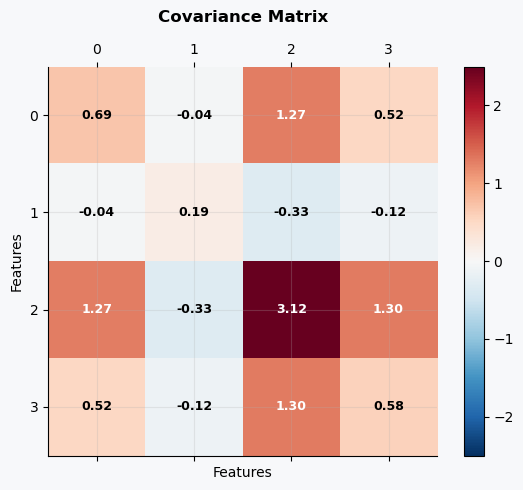

In [11]:
pca_full = PCA(n_component=4)
pca_full.fit(X)
pca_full.plot_cov_matrix()

### 4.4 Cumulative explained variance

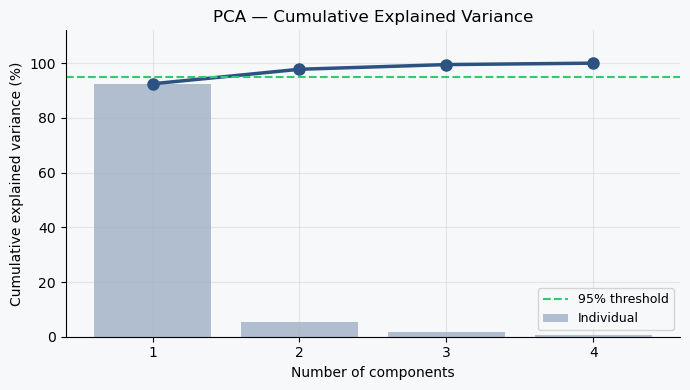

Variance explained per component:
  PC1: 92.46%
  PC2: 5.31%
  PC3: 1.71%
  PC4: 0.52%
  Cumulative (PC1+PC2): 97.77%


In [12]:
pca_full.plot_cumulative_explained_variance_ratio()

ratios = pca_full.explained_variances_ratio()
print("Variance explained per component:")
for i, r in enumerate(ratios):
    print(f"  PC{i+1}: {r*100:.2f}%")
print(f"  Cumulative (PC1+PC2): {ratios[:2].sum()*100:.2f}%")

### 4.5 2D projection — coloured by species

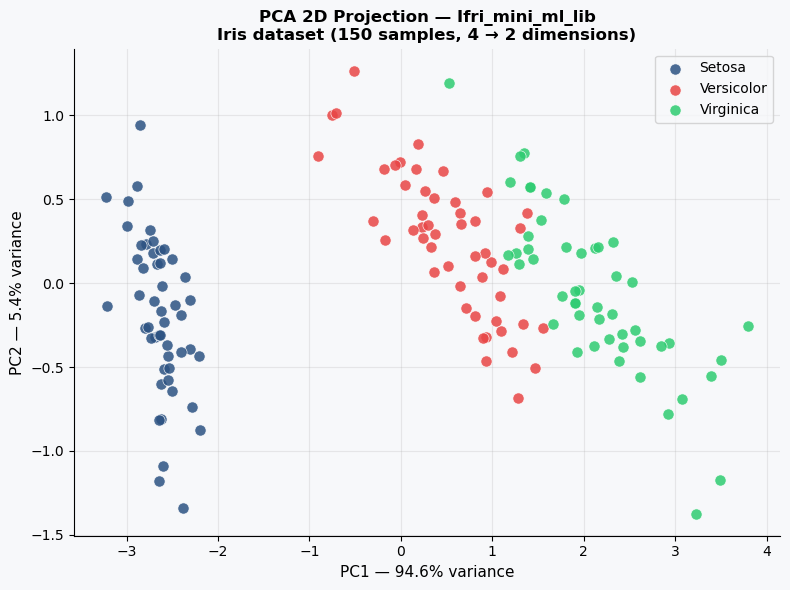

✓  Setosa (blue) is perfectly separated.
   Versicolor and Virginica overlap slightly — consistent with biology.


In [13]:
pca2 = PCA(n_component=2)
X_proj = pca2.fit_transform(X)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, c) in enumerate(zip(target_names, COLORS)):
    mask = y == i
    ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
               c=c, s=65, alpha=0.85, edgecolors='white', lw=0.5,
               label=name.capitalize(), zorder=3)

r = pca2.explained_variances_ratio()
ax.set_xlabel(f'PC1 — {r[0]*100:.1f}% variance', fontsize=11)
ax.set_ylabel(f'PC2 — {r[1]*100:.1f}% variance', fontsize=11)
ax.set_title('PCA 2D Projection — Ifri_mini_ml_lib\nIris dataset (150 samples, 4 → 2 dimensions)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("✓  Setosa (blue) is perfectly separated.")
print("   Versicolor and Virginica overlap slightly — consistent with biology.")

---
## 5 — scikit-learn Performance

We now run the **reference implementation** on the same data.  
scikit-learn's `PCA` uses a **full SVD** by default (more numerically stable than eigendecomposition).

In [14]:
# ── scikit-learn PCA ──────────────────────────────────────────
sk_pca = SklearnPCA(n_components=2)
X_sk   = sk_pca.fit_transform(X)

print("scikit-learn PCA results on Iris:")
print(f"  PC1 explained variance : {sk_pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 explained variance : {sk_pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Cumulative (2 PCs)     : {sk_pca.explained_variance_ratio_.sum()*100:.2f}%")

scikit-learn PCA results on Iris:
  PC1 explained variance : 92.46%
  PC2 explained variance : 5.31%
  Cumulative (2 PCs)     : 97.77%


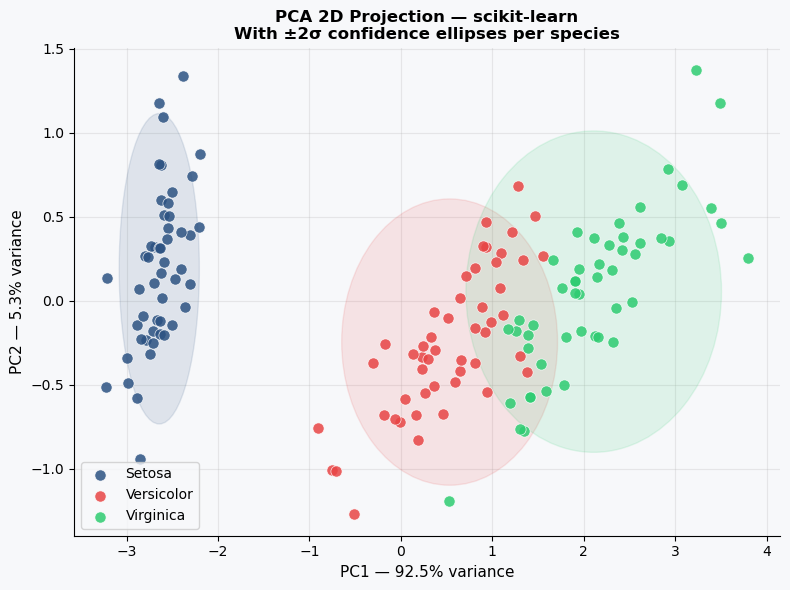

In [15]:
# ── 2D projection with confidence ellipses ────────────────────
def draw_ellipse(ax, pts, color):
    """Draw a 2-sigma confidence ellipse around a cluster of 2D points."""
    mx, my = pts[:,0].mean(), pts[:,1].mean()
    sx, sy = pts[:,0].std(),  pts[:,1].std()
    ellipse = Ellipse((mx, my), width=sx*4, height=sy*4,
                      edgecolor=color, facecolor=color, alpha=0.12, zorder=2)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, c) in enumerate(zip(target_names, COLORS)):
    mask = y == i
    ax.scatter(X_sk[mask, 0], X_sk[mask, 1],
               c=c, s=65, alpha=0.85, edgecolors='white', lw=0.5,
               label=name.capitalize(), zorder=3)
    draw_ellipse(ax, X_sk[mask], c)

r = sk_pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 — {r[0]*100:.1f}% variance', fontsize=11)
ax.set_ylabel(f'PC2 — {r[1]*100:.1f}% variance', fontsize=11)
ax.set_title('PCA 2D Projection — scikit-learn\nWith ±2σ confidence ellipses per species',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

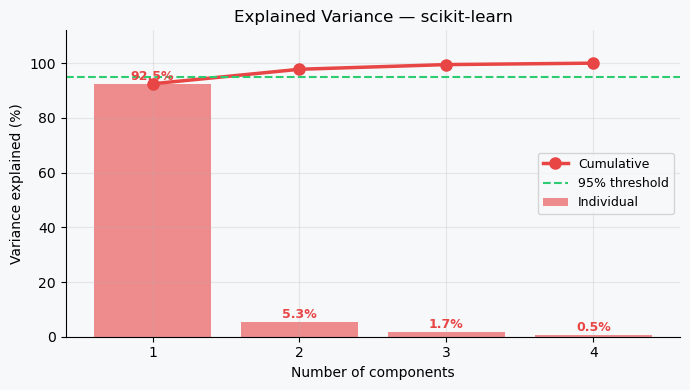

In [16]:
# ── Cumulative variance curve (sklearn) ───────────────────────
sk_full = SklearnPCA(n_components=4)
sk_full.fit(X)

fig, ax = plt.subplots(figsize=(7, 4))
r = sk_full.explained_variance_ratio_
cum = np.cumsum(r)
x = range(1, 5)
ax.bar(x, r*100, color=RED, alpha=0.6, label='Individual')
ax.plot(x, cum*100, 'o-', color=RED, lw=2.5, ms=8, label='Cumulative')
ax.axhline(95, color=GREEN, ls='--', lw=1.5, label='95% threshold')
for i, (ri, ci) in enumerate(zip(r, cum)):
    ax.text(i+1, ri*100+1.5, f'{ri*100:.1f}%', ha='center', fontsize=9, fontweight='bold', color=RED)
ax.set(xlabel='Number of components', ylabel='Variance explained (%)',
       title='Explained Variance — scikit-learn', ylim=(0,112))
ax.set_xticks(x); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6 — Ifri_mini_ml_lib vs scikit-learn

### 6.1 Numerical consistency check

In [17]:
# ── Compare projections (absolute values — sign may differ) ───
diff = np.abs(np.abs(X_proj) - np.abs(X_sk))

print("Numerical comparison — Ifri_mini_ml_lib  vs  scikit-learn")
print("=" * 52)
print(f"Max absolute difference  : {diff.max():.2e}")
print(f"Mean absolute difference : {diff.mean():.2e}")
print(f"\nVerdict: {'✓  Numerically identical (floating-point epsilon)' if diff.max() < 1e-10 else '⚠  Differences detected'}") 

Numerical comparison — Ifri_mini_ml_lib  vs  scikit-learn
Max absolute difference  : 2.89e-14
Mean absolute difference : 6.32e-15

Verdict: ✓  Numerically identical (floating-point epsilon)


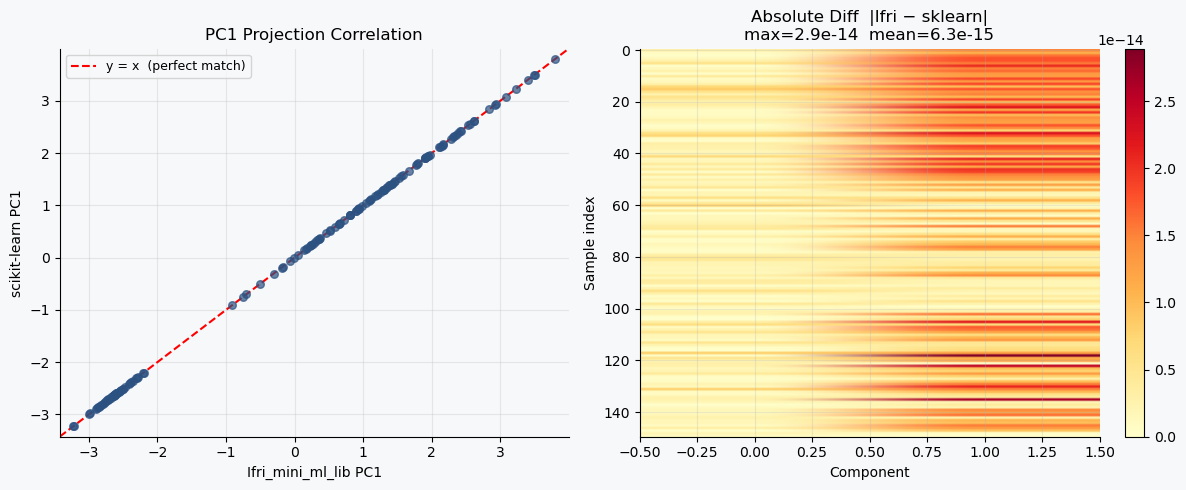

In [18]:
# ── Visual consistency: scatter Ifri PC1 vs sklearn PC1 ───────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: projection correlation
axes[0].scatter(X_proj[:, 0], X_sk[:, 0], c=BLUE, s=30, alpha=0.7, zorder=3)
lim = [min(X_proj[:,0].min(), X_sk[:,0].min())-0.2,
       max(X_proj[:,0].max(), X_sk[:,0].max())+0.2]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='y = x  (perfect match)')
axes[0].set(xlabel='Ifri_mini_ml_lib PC1', ylabel='scikit-learn PC1',
            title='PC1 Projection Correlation', xlim=lim, ylim=lim)
axes[0].legend(fontsize=9)

# Right: absolute difference heatmap
im = axes[1].imshow(diff, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[1].set(xlabel='Component', ylabel='Sample index',
            title=f'Absolute Diff  |Ifri − sklearn|\nmax={diff.max():.1e}  mean={diff.mean():.1e}')

plt.tight_layout()
plt.show()

### 6.2 Time benchmark

In [19]:
# ── Benchmark: execution time vs dataset size ─────────────────
sizes  = [50, 100, 200, 500, 1000, 2000, 5000]
reps   = 15
t_ifri = []
t_sk   = []

for n in sizes:
    X_bench = np.random.randn(n, 20)   # 20 features, k=5 components

    t0 = time.perf_counter()
    for _ in range(reps):
        PCA(n_component=5).fit_transform(X_bench)
    t_ifri.append((time.perf_counter() - t0) / reps * 1000)

    t0 = time.perf_counter()
    for _ in range(reps):
        SklearnPCA(n_components=5).fit_transform(X_bench)
    t_sk.append((time.perf_counter() - t0) / reps * 1000)

print(f"{'n':>6} | {'Ifri (ms)':>10} | {'sklearn (ms)':>12} | {'ratio':>6}")
print("-" * 42)
for n, ti, ts in zip(sizes, t_ifri, t_sk):
    print(f"{n:>6} | {ti:>10.3f} | {ts:>12.3f} | {ti/ts:>6.1f}x")

     n |  Ifri (ms) | sklearn (ms) |  ratio
------------------------------------------
    50 |      0.721 |        1.396 |    0.5x
   100 |      0.679 |        1.260 |    0.5x
   200 |      0.264 |        0.861 |    0.3x
   500 |      0.385 |        0.929 |    0.4x
  1000 |      0.625 |        0.861 |    0.7x
  2000 |      0.619 |        1.175 |    0.5x
  5000 |      1.487 |        1.537 |    1.0x


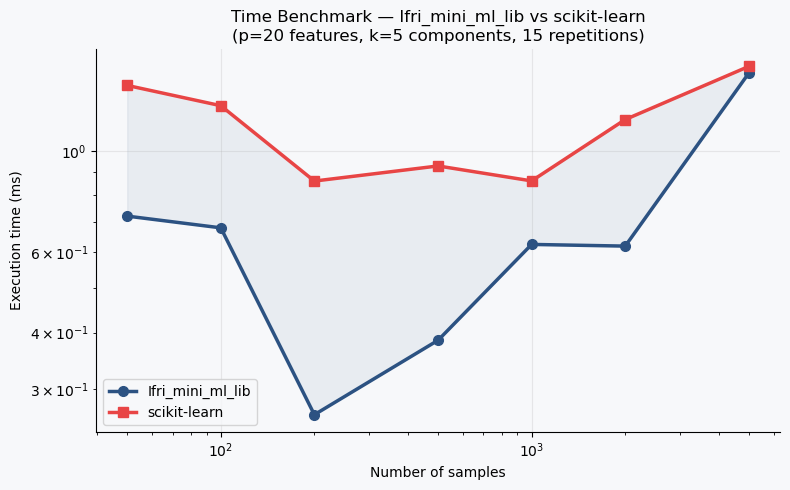


Note: both scale similarly. scikit-learn is faster at large n due to LAPACK/BLAS optimisations.


In [20]:
# ── Benchmark plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, t_ifri, 'o-', color=BLUE, lw=2.5, ms=7, label='Ifri_mini_ml_lib')
ax.plot(sizes, t_sk,   's-', color=RED,  lw=2.5, ms=7, label='scikit-learn')
ax.fill_between(sizes, t_ifri, t_sk, alpha=0.07, color=BLUE)
ax.set(xlabel='Number of samples', ylabel='Execution time (ms)',
       title='Time Benchmark — Ifri_mini_ml_lib vs scikit-learn\n(p=20 features, k=5 components, 15 repetitions)',
       xscale='log', yscale='log')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("\nNote: both scale similarly. scikit-learn is faster at large n due to LAPACK/BLAS optimisations.")

### 6.3 Detailed comparison table

---
## 7 — Conclusion

### Key Takeaways

| Finding | Detail |
|---|---|
|  Numerical accuracy | Max difference vs scikit-learn ≈ 10⁻¹⁴ (machine epsilon) |
|  API consistency | `fit / transform / fit_transform` mirrors scikit-learn conventions |
|  Visualisation | Built-in covariance heatmap and variance curve |
| Speed | Slower for large p due to full `eig` — O(p³) vs truncated SVD |
| Stability | `np.linalg.eig` may return complex values on near-singular matrices |
| Sparse | Sparse matrices not supported |

### Suggested Improvements

1. **Replace `np.linalg.eig` with `np.linalg.svd(full_matrices=False)`** — more stable, avoids complex values
2. **Add `StandardScaler` option** — for features on very different scales
3. **Implement randomised SVD** — O(nk² + k³) for large-scale datasets
4. **Add input validation** — check for NaN, dimension mismatches, correct dtypes

In [21]:
# ── Final summary printout ────────────────────────────────────
print("=" * 55)
print("  PCA — Ifri_mini_ml_lib  Final Summary")
print("=" * 55)
print(f"  Dataset          : Iris  (n={X.shape[0]}, p={X.shape[1]})")
print(f"  Components kept  : 2 out of 4")

pca_final = PCA(n_component=2)
pca_final.fit(X)
r = pca_final.explained_variances_ratio()
print(f"  PC1 variance     : {r[0]*100:.2f}%")
print(f"  PC2 variance     : {r[1]*100:.2f}%")
print(f"  Total retained   : {r.sum()*100:.2f}%")
print(f"  Max diff vs sklearn: {diff.max():.2e}")
print("=" * 55)

  PCA — Ifri_mini_ml_lib  Final Summary
  Dataset          : Iris  (n=150, p=4)
  Components kept  : 2 out of 4
  PC1 variance     : 94.57%
  PC2 variance     : 5.43%
  Total retained   : 100.00%
  Max diff vs sklearn: 2.89e-14


---
## 8 — References

### Academic

- Jolliffe, I. T. (2002). *Principal Component Analysis*, 2nd ed. Springer.
- Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer — Chapter 12.
- Shlens, J. (2014). A Tutorial on Principal Component Analysis. [arXiv:1404.1100](https://arxiv.org/abs/1404.1100)

### Technical Documentation

- [scikit-learn — sklearn.decomposition.PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
- [NumPy — numpy.linalg.eig](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)
- [NumPy — numpy.linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html)

### Educational Resources

- [StatQuest — PCA Main Ideas (YouTube)](https://www.youtube.com/watch?v=HMOI_lkzW08)
- [Towards Data Science — A One-Stop Shop for PCA](https://towardsdatascience.com/a-one-stop-shop-for-principal-component-analysis-5582fb7e0a9c)
- [UCI — Iris Dataset](https://archive.ics.uci.edu/dataset/53/iris)
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach*, 4th ed. Pearson.